# 05 · Evaluación y comparación
Evaluamos **ambos modelos** sobre el conjunto de **test**: matriz de confusión, métricas por clase, curva ROC y **ajuste de umbral** para priorizar el *recall* de la clase patológica.

In [1]:
# =========================================================
# CONFIGURACIÓN  ·  EDITAR BASE_DIR si hace falta
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

import os

# Carpeta de Drive que CONTIENE "Imagenes OK" y "Imagenes Patologicas".
# Ajustá esta ruta a donde estén tus carpetas.
BASE_DIR = '/content/drive/MyDrive/TP_Final Aprendizaje Automatico'

OK_DIR  = os.path.join(BASE_DIR, 'Imagenes OK')
PAT_DIR = os.path.join(BASE_DIR, 'Imagenes Patologicas')

# Carpeta donde se guardará la partición train/val/test (notebook 02)
DATASET_DIR = os.path.join(BASE_DIR, 'dataset')
# Carpeta donde se guardarán los modelos entrenados
MODELS_DIR  = os.path.join(BASE_DIR, 'modelos')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hiperparámetros globales compartidos
IMG_SIZE = (224, 224)
BATCH    = 32
SEED     = 42

# Las carpetas se ordenan alfabéticamente: 'ok'=0, 'patologica'=1
# => la clase POSITIVA (la que nos importa) es 'patologica' = 1
CLASS_NAMES = ['ok', 'patologica']
print('OK_DIR :', OK_DIR)
print('PAT_DIR:', PAT_DIR)

Mounted at /content/drive
OK_DIR : /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes OK
PAT_DIR: /content/drive/MyDrive/TP_Final Aprendizaje Automatico/Imagenes Patologicas


## 1. Reconstruir test set y cargar modelos

In [2]:
import shutil, tensorflow as tf

# Copiamos la partición de Drive al disco local de Colab (lecturas mucho más rápidas)
LOCAL = '/content/dataset'
if os.path.exists(LOCAL):
    shutil.rmtree(LOCAL)
shutil.copytree(DATASET_DIR, LOCAL)

def make_ds(subset, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        os.path.join(LOCAL, subset),
        labels='inferred', label_mode='int',
        class_names=CLASS_NAMES,
        color_mode='rgb', image_size=IMG_SIZE,
        batch_size=BATCH, shuffle=shuffle, seed=SEED,
    )

train_ds = make_ds('train', shuffle=True)
val_ds   = make_ds('val',   shuffle=False)
test_ds  = make_ds('test',  shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

Found 308 files belonging to 2 classes.
Found 66 files belonging to 2 classes.
Found 67 files belonging to 2 classes.


In [3]:
cnn      = tf.keras.models.load_model(os.path.join(MODELS_DIR, 'cnn_desde_cero.keras'))
transfer = tf.keras.models.load_model(os.path.join(MODELS_DIR, 'transfer_mobilenetv2.keras'))

import numpy as np
# Etiquetas reales del test (en orden, sin shuffle)
y_true = np.concatenate([y.numpy().ravel() for _, y in test_ds]).astype(int)
print('Test:', len(y_true), 'imágenes |  patológicas:', y_true.sum())

Test: 67 imágenes |  patológicas: 30


## 2. Probabilidades predichas

In [4]:
def predecir(modelo):
    return modelo.predict(test_ds)[:, 1]   # prob. de la clase patológica (softmax)

prob_cnn      = predecir(cnn)
prob_transfer = predecir(transfer)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 760ms/step


## 3. Matriz de confusión y reporte (umbral 0.5)

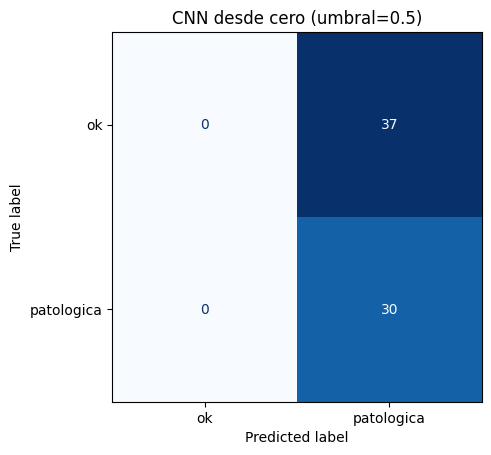

--- CNN desde cero ---
              precision    recall  f1-score   support

          ok      0.000     0.000     0.000        37
  patologica      0.448     1.000     0.619        30

    accuracy                          0.448        67
   macro avg      0.224     0.500     0.309        67
weighted avg      0.200     0.448     0.277        67



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


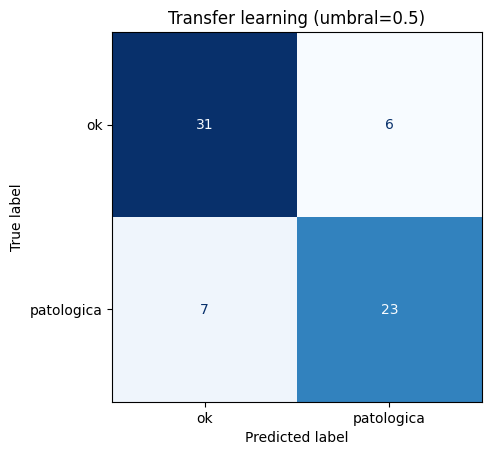

--- Transfer learning ---
              precision    recall  f1-score   support

          ok      0.816     0.838     0.827        37
  patologica      0.793     0.767     0.780        30

    accuracy                          0.806        67
   macro avg      0.804     0.802     0.803        67
weighted avg      0.806     0.806     0.806        67



In [5]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar(nombre, y_prob, umbral=0.5):
    y_pred = (y_prob >= umbral).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(cmap='Blues', colorbar=False)
    plt.title(f'{nombre} (umbral={umbral})'); plt.show()
    print(f'--- {nombre} ---')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=3))

evaluar('CNN desde cero',    prob_cnn)
evaluar('Transfer learning', prob_transfer)

## 4. Curvas ROC

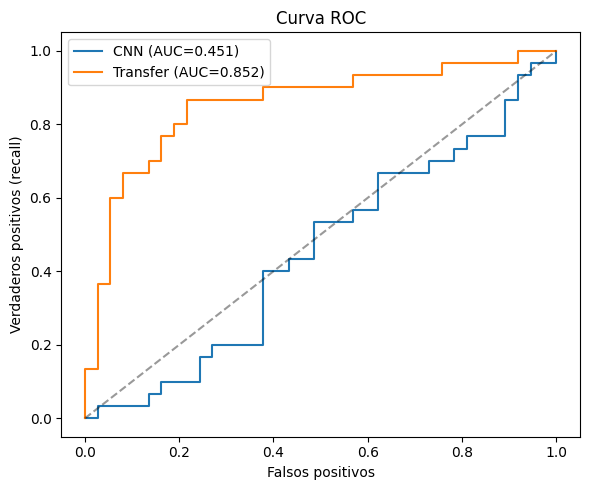

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(6,5))
for nombre, y_prob in [('CNN', prob_cnn), ('Transfer', prob_transfer)]:
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('Falsos positivos'); plt.ylabel('Verdaderos positivos (recall)')
plt.title('Curva ROC'); plt.legend(); plt.tight_layout(); plt.show()

## 5. Ajuste de umbral para priorizar recall

En diagnóstico, un **falso negativo** (decir *sano* a un animal enfermo) es el error más costoso. Bajamos el umbral de decisión para **aumentar el recall** de la clase patológica, observando el costo en precisión.

In [7]:
from sklearn.metrics import precision_score, recall_score
import pandas as pd

def tabla_umbrales(y_prob, umbrales=np.arange(0.1, 0.95, 0.05)):
    filas = []
    for u in umbrales:
        y_pred = (y_prob >= u).astype(int)
        filas.append({
            'umbral': round(u,2),
            'recall_pat':    round(recall_score(y_true, y_pred, zero_division=0), 3),
            'precision_pat': round(precision_score(y_true, y_pred, zero_division=0), 3),
        })
    return pd.DataFrame(filas)

print('Transfer learning:')
tabla = tabla_umbrales(prob_transfer)
display(tabla)

# Umbral mínimo que alcanza recall >= 0.95 (objetivo de seguridad)
OBJETIVO = 0.95
candidatos = tabla[tabla['recall_pat'] >= OBJETIVO]
if len(candidatos):
    elegido = candidatos.iloc[-1]
    print(f"Umbral sugerido para recall>={OBJETIVO}: {elegido['umbral']} "
          f"(precision={elegido['precision_pat']})")
else:
    print('Ningún umbral alcanza el objetivo; revisar el modelo.')

Transfer learning:


,umbral,recall_pat,precision_pat
0,0.10,1.000,0.455
1,0.15,0.967,0.500
2,0.20,0.933,0.538
3,0.25,0.900,0.643
4,0.30,0.867,0.650
5,0.35,0.867,0.684
6,0.40,0.867,0.743
7,0.45,0.833,0.758
8,0.50,0.767,0.793
9,0.55,0.700,0.778


Umbral sugerido para recall>=0.95: 0.15 (precision=0.5)


## 6. Tabla comparativa final

In [8]:
from sklearn.metrics import accuracy_score, f1_score

def resumen(nombre, y_prob, umbral=0.5):
    y_pred = (y_prob >= umbral).astype(int)
    return {
        'modelo': nombre, 'umbral': umbral,
        'accuracy':  round(accuracy_score(y_true, y_pred), 3),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 3),
        'recall':    round(recall_score(y_true, y_pred, zero_division=0), 3),
        'f1':        round(f1_score(y_true, y_pred, zero_division=0), 3),
        'auc':       round(roc_auc_score(y_true, y_prob), 3),
    }

comp = pd.DataFrame([
    resumen('CNN desde cero',    prob_cnn),
    resumen('Transfer (0.5)',    prob_transfer),
    resumen('Transfer (umbral ajustado)', prob_transfer, umbral=0.30),  # ajustar según punto 5
])
comp

,modelo,umbral,accuracy,precision,recall,f1,auc
0,CNN desde cero,0.5,0.448,0.448,1.000,0.619,0.451
1,Transfer (0.5),0.5,0.806,0.793,0.767,0.780,0.852
2,Transfer (umbral ajustado),0.3,0.731,0.650,0.867,0.743,0.852


> Copiá esta tabla a la sección 4.3 del informe. Ajustá el umbral del último renglón al valor elegido en el punto 5.\n\nPróximo paso → **06_gradcam.ipynb**.